# 03 — Clustering
Pipeline: `log1p(R/F/M)` → `StandardScaler` → K-Means.
K is chosen from the **elbow AND silhouette** together — not "K=4 because
RFM tradition".

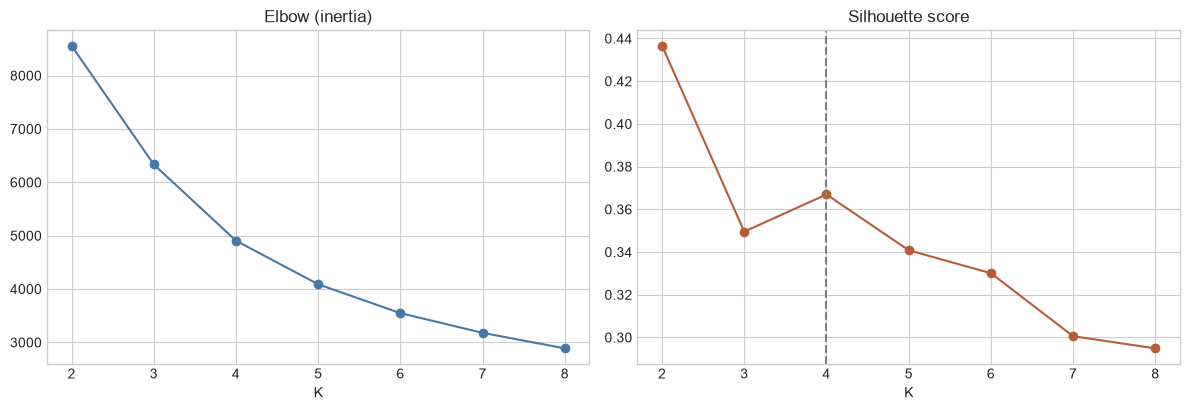

 k  inertia  silhouette
 2 8561.304       0.437
 3 6334.745       0.350
 4 4905.465       0.367
 5 4088.698       0.341
 6 3547.931       0.330
 7 3178.631       0.301
 8 2887.604       0.295
chosen K: 4


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

scores = pd.read_csv("../data/processed/k_selection_scores.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(scores["k"], scores["inertia"], "o-", color="#4878A8")
axes[0].set_title("Elbow (inertia)"); axes[0].set_xlabel("K")
axes[1].plot(scores["k"], scores["silhouette"], "o-", color="#B85C38")
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("K")
nontrivial = scores[scores["k"] >= 3]
best_k = int(nontrivial.loc[nontrivial["silhouette"].idxmax(), "k"])
axes[1].axvline(best_k, ls="--", color="grey")
fig.tight_layout(); fig.savefig("figures/k_selection.png", dpi=150)
plt.show()
print(scores.round(3).to_string(index=False))
print("chosen K:", best_k)

**Why K=4 and not the raw silhouette winner (K=2):** K=2 always scores the
highest silhouette on log-RFM data, but it only separates "active" from
"inactive" — a split with no marketing value. Requiring a non-trivial K ≥ 3,
the silhouette has a clear **local maximum at K=4** (higher than K=3 and
K=5), and K=4 also sits in the elbow region of the inertia curve. That is a
data-driven justification — not "K=4 because RFM tradition".

**Why K-Means over hierarchical:** we also considered agglomerative
clustering; on 5,800+ customers its O(n²) memory is workable but its
dendrogram added no structure beyond what silhouette already shows, and
K-Means centroids give directly interpretable segment profiles. With the
log-scale transform applied, K-Means' spherical-cluster assumption is
reasonable here.

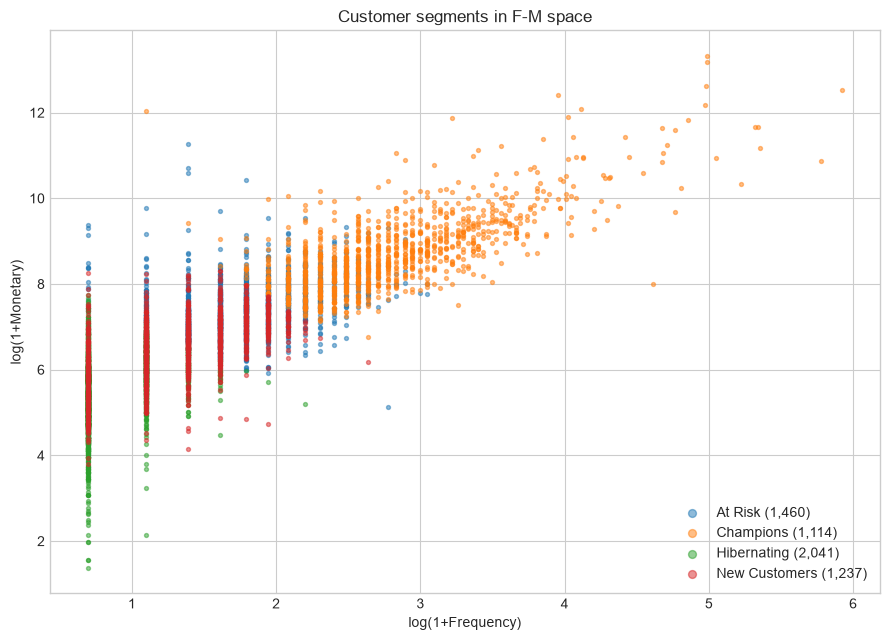

In [2]:
seg = pd.read_parquet("../data/processed/customers_segmented.parquet")
import numpy as np
fig, ax = plt.subplots(figsize=(9, 6.5))
for name, grp in seg.groupby("Segment"):
    ax.scatter(np.log1p(grp["Frequency"]), np.log1p(grp["Monetary"]),
               s=8, alpha=0.5, label=f"{name} ({len(grp):,})")
ax.set_xlabel("log(1+Frequency)"); ax.set_ylabel("log(1+Monetary)")
ax.set_title("Customer segments in F-M space")
ax.legend(markerscale=2)
fig.tight_layout(); fig.savefig("figures/segments_scatter.png", dpi=150)
plt.show()